---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 6. Статичні характеристики та параметри біполярного транзистора</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Вхідні й вихідні статичні характеристики в схемах СЕ і СБ</li>
  <li>Ефект Ерлі (модуляція ширини бази)</li>
  <li>h-параметри та їх визначення за характеристиками</li>
  <li>Робоча точка і навантажувальна пряма</li>
  <li>Залежність β від струму і температури; термостабілізація</li>
  <li>Пробій транзистора, область безпечної роботи</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 6 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Статичні характеристики в схемі СЕ](#ce-characteristics)
    * [⚙️ PySpice: вхідні й вихідні характеристики 2N3904](#spice-ce)
* [Статичні характеристики в схемі СБ](#cb-characteristics)
* [Ефект Ерлі](#early)
* [h-параметри біполярного транзистора](#h-params)
    * [⚙️ PySpice: h-параметри в заданій робочій точці](#spice-h)
* [Навантажувальна пряма і робоча точка](#load-line)
* [Залежність β від режиму і температури](#beta-dependence)
    * [⚙️ PySpice: графік Гуммеля та β(Iк) при різних температурах](#spice-gummel)
    * [⚙️ PySpice: температурна стабілізація робочої точки](#spice-thermal)
* [Пробій і область безпечної роботи](#breakdown-soa)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

def output_family(Ib_list, Uce_max=10.0, step=0.05, model='Q2N3904', T=27):
    """Сімейство вихідних характеристик СЕ: Iк(Uке) при фіксованих Iб (один вкладений DC-аналіз)."""
    c = Circuit('CE output'); c.include(lib('bjt'))
    c.I('b', c.gnd, 'b', 0); c.V('ce', 'c', c.gnd, 0); c.BJT(1, 'c', 'b', c.gnd, model=model)
    ib_step = Ib_list[1] - Ib_list[0]
    an = c.simulator(temperature=T, nominal_temperature=27).dc(Vce=slice(0, Uce_max, step),
                                                               Ib=slice(Ib_list[0], Ib_list[-1] + ib_step/2, ib_step))
    n = int(round(Uce_max/step)) + 1
    U = np.array(an.sweep).reshape(-1, n); I = -np.array(an.branches['vce']).reshape(-1, n)
    return U[0], I

---

# Статичні характеристики в схемі СЕ <a class="anchor" id="ce-characteristics"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Будувати й пояснювати вхідні та вихідні статичні характеристики БТ у схемах СЕ і СБ
> - Пояснювати ефект Ерлі та визначати напругу Ерлі за характеристиками
> - Визначати h-параметри графічно й аналітично та пов'язувати їх з фізичними параметрами
> - Знаходити робочу точку за навантажувальною прямою
> - Пояснювати залежність β від струму колектора і температури та способи термостабілізації
> - Розрізняти види пробою транзистора і будувати область безпечної роботи

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Статичні характеристики** | Залежності між постійними струмами й напругами виводів при фіксованій третій величині |
| **Вхідна характеристика СЕ** | $I_б = f(U_{БЕ})$ при $U_{КЕ} = \text{const}$ |
| **Вихідна характеристика СЕ** | $I_к = f(U_{КЕ})$ при $I_б = \text{const}$ |
| **Напруга Ерлі $U_A$** | Точка $-U_A$ на осі напруг, де перетинаються продовження пологих ділянок вихідних характеристик |
| **h-параметри** | Малосигнальні параметри транзистора як чотириполюсника: $h_{11}$, $h_{12}$, $h_{21}$, $h_{22}$ |
| **ОБР (SOA)** | Область безпечної роботи на площині $(U_{КЕ}, I_к)$ |

**Вхідні характеристики** $I_б = f(U_{БЕ})$ за формою — це пряма гілка ВАХ емітерного переходу: струм бази експоненційно зростає, починаючи з ≈0,5 В. Характеристика при $U_{КЕ} = 0$ проходить **лівіше**: колекторний перехід теж зміщений прямо, і базу живлять обидва переходи (режим насичення). При $U_{КЕ} \ge 1$ В криві майже зливаються (лише трохи зміщуються праворуч через ефект Ерлі: тонша база — менша рекомбінація — менший струм бази).

**Вихідні характеристики** $I_к = f(U_{КЕ})$ при $I_б = \text{const}$ мають чотири області:

- **насичення** — $U_{КЕ} < U_{КЕ.нас}$ ≈ 0,1–0,3 В: круто зростаюча початкова ділянка, КП зміщений прямо, $I_к < \beta I_б$;
- **активна область** — пологі, майже горизонтальні ділянки: $I_к \approx \beta I_б$ з невеликим нахилом (ефект Ерлі);
- **відсічка** — нижче кривої $I_б = 0$: тече лише $I_{КЕО}$;
- **пробій** — різке зростання струму при великих $U_{КЕ}$ (див. кінець лекції).

### ⚙️ PySpice: вхідні й вихідні характеристики 2N3904 <a class="anchor" id="spice-ce"></a>

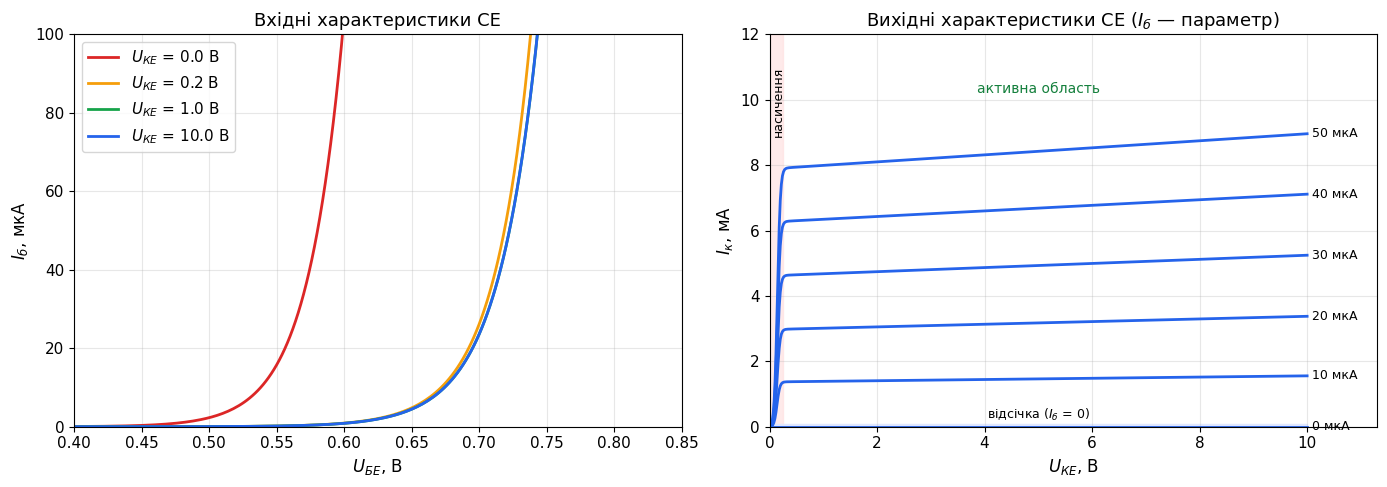

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# вхідні характеристики: Iб(Uбе) при кількох Uке
c = Circuit('CE input'); c.include(lib('bjt'))
c.V('be', 'b', c.gnd, 0); c.V('ce', 'c', c.gnd, 0); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
for Uce, col in [(0.0, '#dc2626'), (0.2, '#f59e0b'), (1.0, '#16a34a'), (10.0, '#2563eb')]:
    c['Vce'].dc_value = Uce
    an = c.simulator().dc(Vbe=slice(0, 0.85, 0.002))
    axes[0].plot(np.array(an.sweep), -np.array(an.branches['vbe'])*1e6, color=col, label=f'$U_{{КЕ}}$ = {Uce} В')
axes[0].set_xlim(0.4, 0.85); axes[0].set_ylim(0, 100)
axes[0].set_xlabel('$U_{БЕ}$, В'); axes[0].set_ylabel('$I_б$, мкА'); axes[0].set_title('Вхідні характеристики СЕ'); axes[0].legend()
# вихідні характеристики
Ib_list = np.arange(0, 60e-6, 10e-6)
U, I = output_family(Ib_list, 10.0, 0.02)
for ib, i in zip(Ib_list, I):
    axes[1].plot(U, i*1e3, color='#2563eb')
    axes[1].text(10.1, i[-1]*1e3, f'{ib*1e6:.0f} мкА', va='center', fontsize=9)
Usat = np.linspace(0, 0.4, 50)
axes[1].fill_between([0, 0.25], 0, 12, color='#fee2e2', alpha=0.7); axes[1].text(0.05, 11, 'насичення', rotation=90, fontsize=9, va='top')
axes[1].fill_between([0, 10], 0, 0.08, color='#e0e7ff'); axes[1].text(5, 0.25, 'відсічка ($I_б$ = 0)', ha='center', fontsize=9)
axes[1].text(5, 10.2, 'активна область', ha='center', fontsize=10, color='#15803d')
axes[1].set_xlim(0, 11.3); axes[1].set_ylim(0, 12)
axes[1].set_xlabel('$U_{КЕ}$, В'); axes[1].set_ylabel('$I_к$, мА'); axes[1].set_title('Вихідні характеристики СЕ ($I_б$ — параметр)')
plt.tight_layout(); plt.show()

---

# Статичні характеристики в схемі СБ <a class="anchor" id="cb-characteristics"></a>

У схемі зі спільною базою вхідна величина — струм емітера, вихідна — струм колектора. **Вихідні характеристики** $I_к = f(U_{КБ})$ при $I_е = \text{const}$ майже горизонтальні і рівновіддалені: $I_к = \alpha I_е$ **вже при $U_{КБ} = 0$** — носії екстрагує вбудоване поле колекторного переходу. Щоб струм колектора зменшився до нуля, колекторний перехід треба змістити **прямо** на 0,5–0,7 В (протилежна інжекція з колектора компенсує потік з емітера). Нахил характеристик у СБ набагато менший, ніж у СЕ: вихідний опір у СБ більший приблизно в $\beta$ разів.

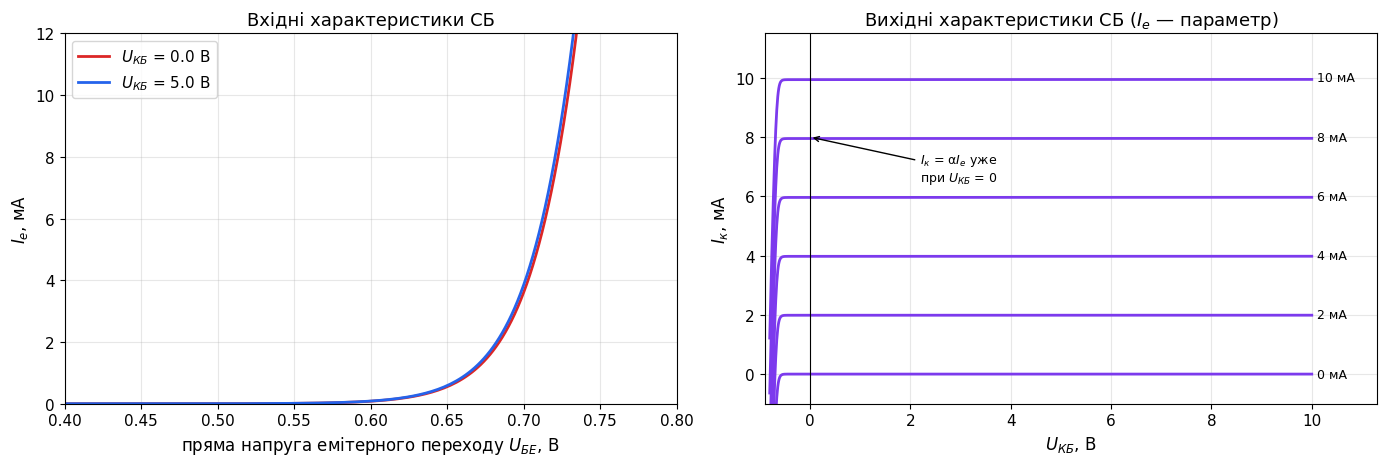

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
c = Circuit('CB'); c.include(lib('bjt'))
c.I('e', 'e', c.gnd, 0); c.V('cb', 'c', c.gnd, 0); c.BJT(1, 'c', c.gnd, 'e', model='Q2N3904')     # база — на землі
for Ie in np.arange(0, 12e-3, 2e-3):
    c['Ie'].dc_value = Ie
    an = c.simulator().dc(Vcb=slice(-0.8, 10, 0.01))
    axes[1].plot(np.array(an.sweep), -np.array(an.branches['vcb'])*1e3, color='#7c3aed')
    axes[1].text(10.1, Ie*1e3, f'{Ie*1e3:.0f} мА', va='center', fontsize=9)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlim(-0.9, 11.3); axes[1].set_ylim(-1, 11.5)
axes[1].set_xlabel('$U_{КБ}$, В'); axes[1].set_ylabel('$I_к$, мА'); axes[1].set_title('Вихідні характеристики СБ ($I_е$ — параметр)')
axes[1].annotate('$I_к$ = α$I_е$ уже\nпри $U_{КБ}$ = 0', xy=(0, 8), xytext=(2.2, 6.5), arrowprops=dict(arrowstyle='->'), fontsize=9)
c2 = Circuit('CB in'); c2.include(lib('bjt'))
c2.V('eb', c2.gnd, 'e', 0); c2.V('cb', 'c', c2.gnd, 0); c2.BJT(1, 'c', c2.gnd, 'e', model='Q2N3904')
for Ucb, col in [(0.0, '#dc2626'), (5.0, '#2563eb')]:
    c2['Vcb'].dc_value = Ucb
    an = c2.simulator().dc(Veb=slice(0, 0.8, 0.002))
    axes[0].plot(np.array(an.sweep), -np.array(an.branches['veb'])*1e3, color=col, label=f'$U_{{КБ}}$ = {Ucb} В')
axes[0].set_xlim(0.4, 0.8); axes[0].set_ylim(0, 12)
axes[0].set_xlabel('пряма напруга емітерного переходу $U_{БЕ}$, В')
axes[0].set_ylabel('$I_е$, мА'); axes[0].set_title('Вхідні характеристики СБ'); axes[0].legend()
plt.tight_layout(); plt.show()

---

# Ефект Ерлі <a class="anchor" id="early"></a>

Зі збільшенням зворотної напруги на колекторному переході його ОПЗ розширюється, зокрема **в базу**, тому ефективна ширина бази $W_{еф}$ зменшується (**модуляція ширини бази**, ефект Ерлі, 1952). Наслідки:

- градієнт концентрації неосновних носіїв у базі зростає → $I_к$ зростає з $U_{КЕ}$ (нахил вихідних характеристик);
- менше носіїв рекомбінує в базі → $\beta$ зростає;
- при граничному звуженні бази до нуля настає **прокол бази** (punch-through).

Продовження пологих ділянок вихідних характеристик перетинаються приблизно в одній точці $-U_A$ на осі напруг, де $U_A$ — **напруга Ерлі** (50–200 В для малопотужних транзисторів). З урахуванням ефекту Ерлі

$$I_к = \beta I_б\left(1 + \frac{U_{КЕ}}{U_A}\right), \qquad r_{ке} = \frac{1}{h_{22е}} = \frac{U_A + U_{КЕ}}{I_к}.$$

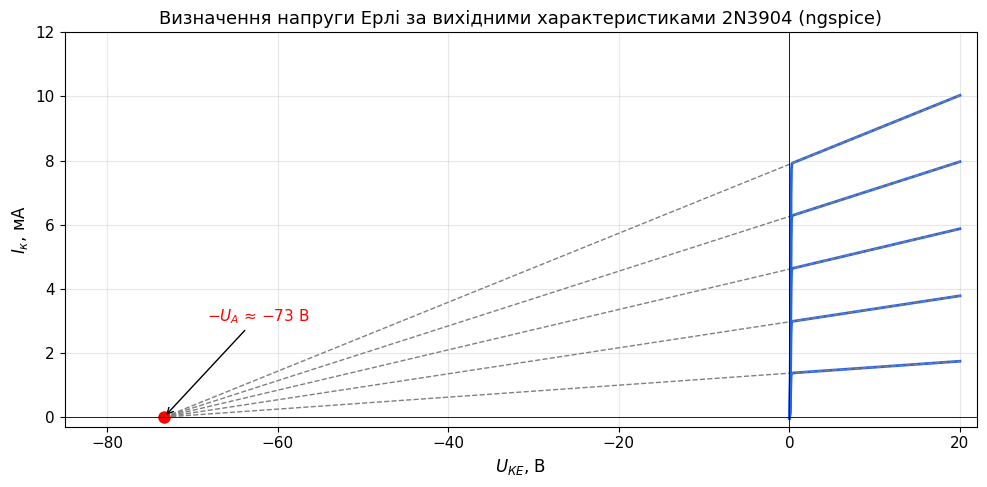

Напруга Ерлі за розрахунком: U_A ≈ 73.3 В (параметр моделі VAF = 74 В)


In [4]:
Ib_list = np.arange(10e-6, 60e-6, 10e-6)
U, I = output_family(Ib_list, 20.0, 0.05)
fig, ax = plt.subplots(figsize=(10, 5))
VA_est = []
for i in I:
    m = (U > 5) & (U < 18); p = np.polyfit(U[m], i[m], 1)
    VA_est.append(p[1]/p[0])
    ax.plot(U, i*1e3, color='#2563eb', lw=2)
    ux = np.linspace(-p[1]/p[0], 20, 50); ax.plot(ux, np.polyval(p, ux)*1e3, '--', color='gray', lw=1)
VA = np.mean(VA_est)
ax.plot(-VA, 0, 'ro', ms=8); ax.annotate(f'$-U_A$ ≈ −{VA:.0f} В', xy=(-VA, 0), xytext=(-VA + 5, 3), arrowprops=dict(arrowstyle='->'), color='r')
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('$U_{КЕ}$, В'); ax.set_ylabel('$I_к$, мА'); ax.set_title('Визначення напруги Ерлі за вихідними характеристиками 2N3904 (ngspice)')
ax.set_xlim(-85, 22); ax.set_ylim(-0.3, 12)
plt.tight_layout(); plt.show()
print(f'Напруга Ерлі за розрахунком: U_A ≈ {VA:.1f} В (параметр моделі VAF = 74 В)')

---

# h-параметри біполярного транзистора <a class="anchor" id="h-params"></a>

Для малих змінних сигналів навколо робочої точки транзистор описують як **лінійний чотириполюсник**. Найзручніші для БТ — **гібридні h-параметри**, бо їх легко виміряти: вхід транзистора має малий опір (зручно задавати струм), вихід — великий (зручно задавати напругу):

$$\begin{cases} u_1 = h_{11}i_1 + h_{12}u_2 \\ i_2 = h_{21}i_1 + h_{22}u_2 \end{cases} \qquad \text{для СЕ: } u_1 = u_{бе},\; i_1 = i_б,\; u_2 = u_{ке},\; i_2 = i_к.$$

| Параметр | Визначення | Фізичний зміст | Типове значення (СЕ) |
|---|---|---|---|
| $h_{11е}$ | $\Delta U_{БЕ}/\Delta I_б$ при $U_{КЕ}$ = const | вхідний опір | 1–10 кОм |
| $h_{12е}$ | $\Delta U_{БЕ}/\Delta U_{КЕ}$ при $I_б$ = const | коефіцієнт внутрішнього зворотного зв'язку за напругою | $10^{-4}$–$10^{-3}$ |
| $h_{21е}$ | $\Delta I_к/\Delta I_б$ при $U_{КЕ}$ = const | коефіцієнт передачі струму ($\beta$) | 50–500 |
| $h_{22е}$ | $\Delta I_к/\Delta U_{КЕ}$ при $I_б$ = const | вихідна провідність | 5–100 мкСм |

**Графічне визначення:** $h_{11е}$ і $h_{12е}$ — за вхідними характеристиками (нахил кривої і зсув між кривими), $h_{21е}$ і $h_{22е}$ — за вихідними (відстань між кривими і нахил кривої). **Зв'язок з фізичними параметрами** (Т-подібна схема заміщення):

$$h_{11е} = r_б + (\beta + 1)r_е, \quad r_е = \frac{\varphi_T}{I_е}; \qquad h_{21е} = \beta; \qquad h_{22е} \approx \frac{I_к}{U_A + U_{КЕ}}; \qquad g_m = \frac{I_к}{\varphi_T} = \frac{h_{21е}}{h_{11е}}\ (\text{при } r_б \to 0).$$

### ⚙️ PySpice: h-параметри в заданій робочій точці <a class="anchor" id="spice-h"></a>

Робоча точка задається струмом бази і напругою $U_{КЕ}$. ngspice розраховує робочу точку й малі прирости (±1 %) — точно так, як h-параметри визначають за характеристиками методом двох точок. Для порівняння наведено розрахунок за фізичними формулами ($r_б$ = 10 Ом, $U_A$ = 74 В з моделі).

In [5]:
def op_point(Ib, Uce):
    c = Circuit('h'); c.include(lib('bjt'))
    c.I('b', c.gnd, 'b', Ib); c.V('ce', 'c', c.gnd, Uce); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
    op = c.simulator().operating_point()
    return float(op['b'][0]), -float(op.branches['vce'][0])

def h_params(Ib_uA=20, Uce=5.0):
    Ib = Ib_uA*1e-6; dI, dU = 0.01*Ib, 0.05
    Ube0, Ic0 = op_point(Ib, Uce)
    Ube_p, Ic_p = op_point(Ib + dI, Uce); Ube_m, Ic_m = op_point(Ib - dI, Uce)
    Ube_u, Ic_u = op_point(Ib, Uce + dU); Ube_d, Ic_d = op_point(Ib, Uce - dU)
    h11 = (Ube_p - Ube_m)/(2*dI); h21 = (Ic_p - Ic_m)/(2*dI)
    h12 = (Ube_u - Ube_d)/(2*dU); h22 = (Ic_u - Ic_d)/(2*dU)
    beta_dc = Ic0/Ib; re = phi_T(300.15)/(Ic0 + Ib)
    print(f'Робоча точка: I_б = {Ib_uA} мкА, U_КЕ = {Uce} В  →  I_к = {Ic0*1e3:.3f} мА, U_БЕ = {Ube0:.4f} В, β = I_к/I_б = {beta_dc:.1f}')
    print(f'h11е = {h11/1e3:7.3f} кОм   | теорія r_б + (β+1)·φT/I_е = {(10 + (h21 + 1)*re)/1e3:.3f} кОм')
    print(f'h12е = {h12:9.2e}     | (дуже малий: вплив виходу на вхід)')
    print(f'h21е = {h21:7.1f}       | статичний β = {beta_dc:.1f}')
    print(f'h22е = {h22*1e6:7.2f} мкСм  | теорія I_к/(U_A + U_КЕ) = {Ic0/(74 + Uce)*1e6:.2f} мкСм  → r_ке = {1/h22/1e3:.0f} кОм')
    print(f'крутизна g_m = I_к/φT = {Ic0/phi_T(300.15)*1e3:.1f} мА/В;  h21е/h11е = {h21/h11*1e3:.1f} мА/В')

interact(h_params, Ib_uA=widgets.IntSlider(min=2, max=100, step=2, value=20, description='$I_б$, мкА', continuous_update=False),
         Uce=widgets.FloatSlider(min=1, max=20, step=0.5, value=5, description='$U_{КЕ}$, В', continuous_update=False));

interactive(children=(IntSlider(value=20, continuous_update=False, description='$I_б$, мкА', min=2, step=2), F…

---

# Навантажувальна пряма і робоча точка <a class="anchor" id="load-line"></a>

У каскаді СЕ колектор живиться від джерела $E_к$ через резистор $R_к$: $U_{КЕ} = E_к - I_кR_к$. На сімействі вихідних характеристик це **навантажувальна пряма** через точки $(E_к, 0)$ — відсічка — і $(0, E_к/R_к)$ — «коротке замикання». **Робоча точка** (точка спокою) — перетин прямої з характеристикою при заданому $I_б$. Для лінійного підсилення її розміщують посередині активної області ($U_{КЕ} \approx E_к/2$). Для ключа транзистор перемикають між точками **відсічки** і **насичення**.

In [6]:
Ib_fam = np.arange(0, 110e-6, 10e-6)
U_ll, I_ll = output_family(Ib_fam, 15.0, 0.02)

def load_line(Ek=12.0, Rk_kOhm=2.0, Ib_uA=20):
    Rk = Rk_kOhm*1e3
    c = Circuit('Q'); c.include(lib('bjt'))
    c.V('k', 'vk', c.gnd, Ek); c.R('k', 'vk', 'c', Rk); c.I('b', c.gnd, 'b', Ib_uA*1e-6); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
    op = c.simulator().operating_point(); Uq = float(op['c'][0]); Iq = (Ek - Uq)/Rk
    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    for ib, i in zip(Ib_fam, I_ll):
        ax.plot(U_ll, i*1e3, color='#93c5fd', lw=1.3)
        if ib > 0: ax.text(15.1, i[-1]*1e3, f'{ib*1e6:.0f}', fontsize=8, va='center', color='#2563eb')
    ax.text(15.1, I_ll[-1][-1]*1e3 + 1.3, '$I_б$, мкА', fontsize=8, color='#2563eb')
    ax.plot([0, Ek], [Ek/Rk*1e3, 0], 'k-', lw=2, label=f'навантажувальна пряма ($E_к$ = {Ek} В, $R_к$ = {Rk_kOhm} кОм)')
    ax.plot(Uq, Iq*1e3, 'ro', ms=9, label=f'робоча точка: {Uq:.2f} В, {Iq*1e3:.2f} мА')
    ax.set_xlim(0, 16.5); ax.set_ylim(0, max(20, Ek/Rk*1e3*1.05)); ax.set_xlabel('$U_{КЕ}$, В'); ax.set_ylabel('$I_к$, мА')
    ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2); ax.set_title('Графоаналітичне визначення робочої точки (2N3904)')
    plt.tight_layout(); plt.show()
    Ube = float(op['b'][0]); mode = 'НАСИЧЕННЯ' if Uq < Ube else ('ВІДСІЧКА' if Ib_uA == 0 else 'АКТИВНИЙ')
    print(f'Режим: {mode}.  U_КЕ = {Uq:.2f} В, I_к = {Iq*1e3:.2f} мА, U_БЕ = {Ube:.3f} В;  I_к/I_б = {Iq/(Ib_uA*1e-6):.0f}' if Ib_uA else f'Режим: {mode}')
    if mode == 'НАСИЧЕННЯ': print(f'Ступінь насичення S = β·I_б/I_к.нас ≈ {165*Ib_uA*1e-6/Iq:.1f}')

interact(load_line, Ek=widgets.FloatSlider(min=3, max=15, step=0.5, value=12, description='$E_к$, В', continuous_update=False),
         Rk_kOhm=widgets.FloatSlider(min=0.2, max=10, step=0.1, value=2.0, description='$R_к$, кОм', continuous_update=False),
         Ib_uA=widgets.IntSlider(min=0, max=100, step=5, value=20, description='$I_б$, мкА', continuous_update=False));

interactive(children=(FloatSlider(value=12.0, continuous_update=False, description='$E_к$, В', max=15.0, min=3…

---
### ✅ Питання для самоперевірки: Статичні характеристики та h-параметри

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому вхідна характеристика СЕ при $U_{КЕ} = 0$ лежить лівіше за характеристики при $U_{КЕ} > 1$ В?</summary>

> **Відповідь:** При $U_{КЕ} = 0$ колекторний перехід зміщений прямо так само, як емітерний, — транзистор у глибокому насиченні, і в базу інжектують обидва переходи. Струм бази — сума двох «діодних» струмів, тому при тій самій $U_{БЕ}$ він більший.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Як за вихідними характеристиками визначити $h_{21е}$ і $h_{22е}$?</summary>

> **Відповідь:** $h_{21е}$ — відношення приросту $I_к$ між двома сусідніми кривими до різниці їх $I_б$ при одній $U_{КЕ}$; $h_{22е}$ — нахил однієї кривої в активній області, $\Delta I_к/\Delta U_{КЕ}$ при сталому $I_б$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому в схемі СБ колекторний струм не зменшується до нуля при $U_{КБ} = 0$?</summary>

> **Відповідь:** Носії, які дійшли до колекторного переходу, екстрагує вбудоване поле переходу (контактна різниця потенціалів) — зовнішня напруга для цього не потрібна. Струм припиняється лише тоді, коли пряма напруга на КП створює зустрічну інжекцію.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Як зміниться $h_{11е}$, якщо струм колектора збільшити вдвічі?</summary>

> **Відповідь:** Приблизно зменшиться вдвічі: $h_{11е} \approx (\beta + 1)\varphi_T/I_е$ обернено пропорційний струму (якщо знехтувати $r_б$ і зміною β).

</details>

---

# Залежність β від режиму і температури <a class="anchor" id="beta-dependence"></a>

**Від струму колектора** $\beta$ залежить «дзвоноподібно»:

- при **малих** струмах β зменшується: у струмі бази переважає рекомбінація в ОПЗ емітерного переходу ($\propto e^{U_{БЕ}/2\varphi_T}$), а колекторний струм зростає як $e^{U_{БЕ}/\varphi_T}$;
- у **середньому** діапазоні β максимальний і найстабільніший — тут вибирають робочу точку;
- при **великих** струмах β знову спадає: високий рівень інжекції в базі (ефект Вебстера) і розширення бази в колектор (ефект Кірка).

Найнаочніше ці ефекти видно на **графіку Гуммеля** — $\lg I_к$ і $\lg I_б$ як функції $U_{БЕ}$: відстань між кривими в логарифмічному масштабі дорівнює $\lg\beta$.

**Від температури:** β зростає приблизно на 0,5–1 %/°C (збільшується час життя, зменшується вплив рекомбінаційних центрів). Разом зі зменшенням $U_{БЕ}$ (−2 мВ/°C при сталому струмі) і зростанням $I_{КБО}$ (подвоюється кожні ≈10 °C) це робить колекторний струм **термонестабільним**. При фіксованому струмі бази нагрівання збільшує $I_к$, потужність і, отже, ще більше нагрівання — можливий **тепловий розгін** (thermal runaway).

### ⚙️ PySpice: графік Гуммеля та β(Iк) при різних температурах <a class="anchor" id="spice-gummel"></a>

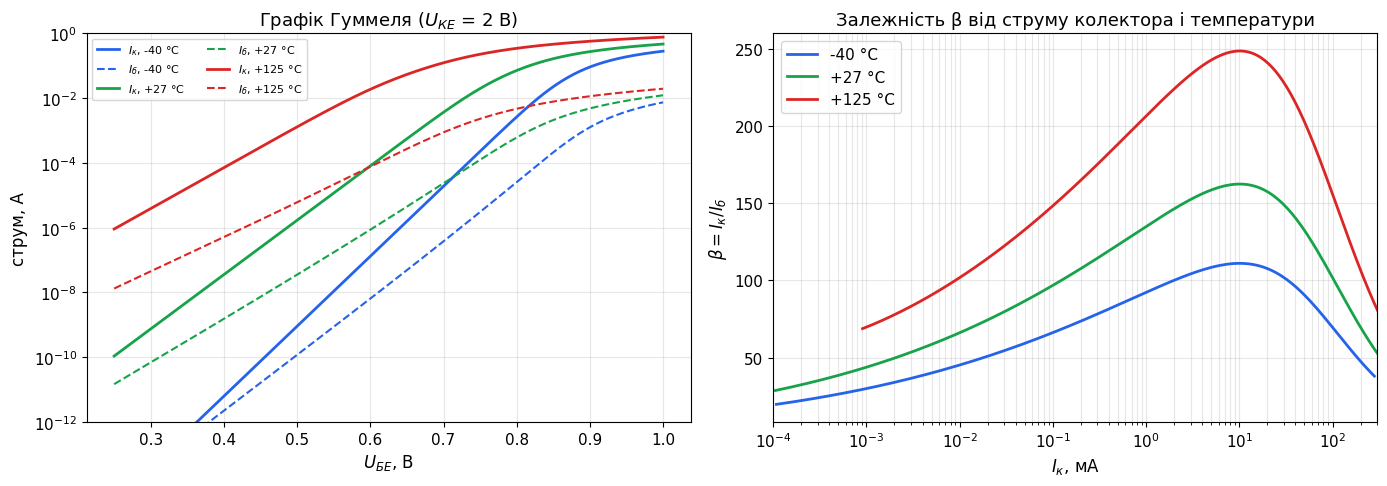

In [7]:
def gummel(T_list=(-40, 27, 125)):
    c = Circuit('Gummel'); c.include(lib('bjt'))
    c.V('be', 'b', c.gnd, 0.6); c.V('ce', 'c', c.gnd, 2.0); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for T, col in zip(T_list, ['#2563eb', '#16a34a', '#dc2626']):
        sim = c.simulator(temperature=T, nominal_temperature=27); sim.options(gmin=1e-20)   # без паразитної GMIN
        an = sim.dc(Vbe=slice(0.25, 1.0, 0.002))
        U = np.array(an.sweep); Ic = -np.array(an.branches['vce']); Ib = -np.array(an.branches['vbe'])
        axes[0].semilogy(U, Ic, color=col, lw=2, label=f'$I_к$, {T:+d} °C'); axes[0].semilogy(U, Ib, '--', color=col, lw=1.5, label=f'$I_б$, {T:+d} °C')
        m = Ic > 1e-7
        axes[1].semilogx(Ic[m]*1e3, Ic[m]/Ib[m], color=col, lw=2, label=f'{T:+d} °C')
    axes[0].set_ylim(1e-12, 1); axes[0].set_xlabel('$U_{БЕ}$, В'); axes[0].set_ylabel('струм, А'); axes[0].legend(fontsize=8, ncol=2)
    axes[0].set_title('Графік Гуммеля ($U_{КЕ}$ = 2 В)'); axes[0].grid(True, which='both', alpha=0.3)
    axes[1].set_xlabel('$I_к$, мА'); axes[1].set_ylabel(r'$\beta = I_к/I_б$'); axes[1].set_title('Залежність β від струму колектора і температури')
    axes[1].set_xlim(1e-4, 300); axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()

gummel()

### ⚙️ PySpice: температурна стабілізація робочої точки <a class="anchor" id="spice-thermal"></a>

Порівнюються три способи задати робочу точку каскаду СЕ ($E_к$ = 12 В, $R_к$ = 2 кОм, $I_к$ ≈ 3 мА при 27 °C):

1. **фіксований струм бази** — резистор $R_б$ від $E_к$ до бази;
2. **колекторний зворотний зв'язок** — $R_б$ від колектора до бази;
3. **емітерна стабілізація** — дільник $R_1$, $R_2$ у колі бази і резистор $R_е$ в емітері (найпоширеніша схема).

Температура змінюється від −40 до +125 °C; розрахунок ngspice враховує зміну $\beta$, $U_{БЕ}$ і $I_S$ транзистора 2N3904.

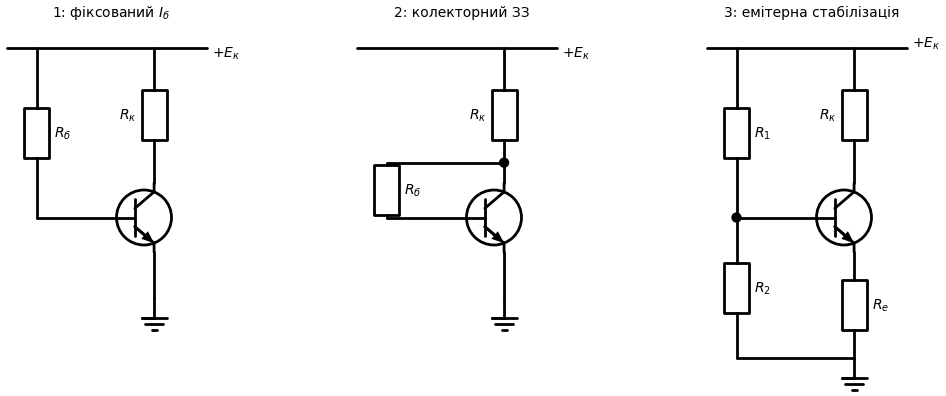

In [8]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=10, unit=2) as d:
        def stage(x0, kind, title):
            top = 5.0
            d.add(elm.Line().endpoints((x0, top), (x0 + 4, top)))
            d.add(elm.Label().at((x0 + 2, top + 0.6)).label(title, fontsize=10))
            t = d.add(elm.BjtNpn(circle=True).at((x0 + 2.2, 1.6)).theta(0))
            d.add(elm.Resistor().endpoints((t.collector[0], top), t.collector).label('$R_к$'))
            if kind == 1:
                d.add(elm.Resistor().endpoints((x0 + 0.6, top), (x0 + 0.6, t.base[1])).label('$R_б$', loc='bottom'))
                d.add(elm.Line().endpoints((x0 + 0.6, t.base[1]), t.base))
                d.add(elm.Line().endpoints(t.emitter, (t.emitter[0], 0))); d.add(elm.Ground().at((t.emitter[0], 0)))
            elif kind == 2:
                d.add(elm.Dot().at((t.collector[0], t.collector[1] + 0.4)))
                d.add(elm.Line().endpoints((t.collector[0], t.collector[1] + 0.4), (x0 + 0.6, t.collector[1] + 0.4)))
                d.add(elm.Resistor().endpoints((x0 + 0.6, t.collector[1] + 0.4), (x0 + 0.6, t.base[1])).label('$R_б$', loc='bottom'))
                d.add(elm.Line().endpoints((x0 + 0.6, t.base[1]), t.base))
                d.add(elm.Line().endpoints(t.emitter, (t.emitter[0], 0))); d.add(elm.Ground().at((t.emitter[0], 0)))
            else:
                d.add(elm.Resistor().endpoints((x0 + 0.6, top), (x0 + 0.6, t.base[1])).label('$R_1$', loc='bottom'))
                d.add(elm.Dot().at((x0 + 0.6, t.base[1]))); d.add(elm.Line().endpoints((x0 + 0.6, t.base[1]), t.base))
                d.add(elm.Resistor().endpoints((x0 + 0.6, t.base[1]), (x0 + 0.6, -1.2)).label('$R_2$', loc='bottom'))
                d.add(elm.Resistor().endpoints(t.emitter, (t.emitter[0], -1.2)).label('$R_е$', loc='bottom'))
                d.add(elm.Line().endpoints((x0 + 0.6, -1.2), (t.emitter[0], -1.2))); d.add(elm.Ground().at((t.emitter[0], -1.2)))
            d.add(elm.Label().at((x0 + 4.3, top)).label('$+E_к$'))
        stage(0, 1, '1: фіксований $I_б$'); stage(7, 2, '2: колекторний ЗЗ'); stage(14, 3, '3: емітерна стабілізація')

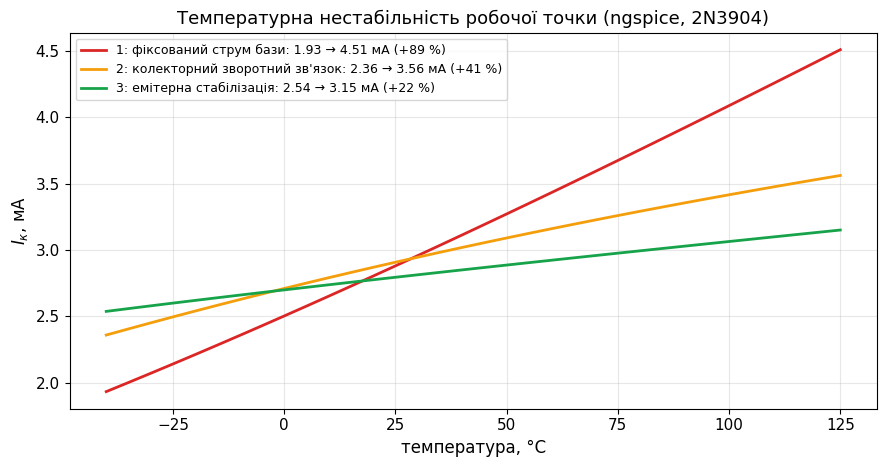

In [9]:
def bias_vs_T():
    T = np.arange(-40, 126, 5.0)
    Ek, Rk = 12.0, 2e3
    def build(kind):
        c = Circuit('bias'); c.include(lib('bjt')); c.V('k', 'vk', c.gnd, Ek); c.R('k', 'vk', 'c', Rk)
        if kind == 1: c.R('b', 'vk', 'b', 620e3); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
        if kind == 2: c.R('b', 'c', 'b', 300e3); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
        if kind == 3:
            c.R('1', 'vk', 'b', 33e3); c.R('2', 'b', c.gnd, 8.2e3); c.R('e', 'e', c.gnd, 560)
            c.BJT(1, 'c', 'b', 'e', model='Q2N3904')
        return c
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for kind, lab, col in [(1, '1: фіксований струм бази', '#dc2626'), (2, '2: колекторний зворотний зв\'язок', '#f59e0b'),
                           (3, '3: емітерна стабілізація', '#16a34a')]:
        Ic = []
        for t in T:
            op = build(kind).simulator(temperature=t, nominal_temperature=27).operating_point()
            Ic.append((Ek - float(op['c'][0]))/Rk)
        Ic = np.array(Ic); i27 = Ic[np.argmin(abs(T - 27))]
        ax.plot(T, Ic*1e3, color=col, lw=2, label=f'{lab}: {Ic[0]*1e3:.2f} → {Ic[-1]*1e3:.2f} мА ({(Ic[-1]-Ic[0])/i27*100:+.0f} %)')
    ax.set_xlabel('температура, °C'); ax.set_ylabel('$I_к$, мА'); ax.set_title('Температурна нестабільність робочої точки (ngspice, 2N3904)')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

bias_vs_T()

---
### ⚡ Практичне застосування: Чому емітерна стабілізація — стандарт

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Резистор $R_е$ створює **від'ємний зворотний зв'язок за постійним струмом**: якщо $I_к$ зростає (нагрів, заміна транзистора з іншим β), зростає спад $I_еR_е$, напруга $U_{БЕ} = U_б - I_еR_е$ зменшується, і струм повертається назад. Якщо дільник у колі бази «жорсткий» (струм дільника ≫ $I_б$), то $I_к \approx (U_б - U_{БЕ})/R_е$ майже не залежить від β. Щоб $R_е$ не зменшував підсилення змінного сигналу, його шунтують конденсатором (Лекція 7).

</div>

---

# Пробій і область безпечної роботи <a class="anchor" id="breakdown-soa"></a>

**Лавинний пробій колекторного переходу.** При великій зворотній напрузі в ОПЗ колектора починається лавинне множення з коефіцієнтом $M = 1/[1 - (U/U_{проб})^n]$. При **розімкненому емітері** пробій настає при $U_{КБО.проб}$ (BVCBO) — це пробій ізольованого колекторного переходу. При **розімкненій базі** додаткові носії від лавинного множення діють як струм бази і підсилюються транзистором, тому пробій настає, коли $\alpha M = 1$, тобто при значно меншій напрузі:

$$U_{КЕО.проб} = \frac{U_{КБО.проб}}{\sqrt[n]{\beta + 1}}.$$

Якщо база з'єднана з емітером через резистор $R$ ($U_{КЕR}$) або накоротко ($U_{КЕS}$), пробивна напруга проміжна. **Прокол бази** — змикання ОПЗ колекторного і емітерного переходів у тонкій базі.

**Вторинний пробій** — у потужних транзисторах при одночасно великих напрузі й струмі струм «шнурується» в гарячих точках (неоднорідність легування, додатний ТКС струму), локальний перегрів лавиноподібно розвивається і руйнує кристал. На ВАХ з'являється ділянка з різким спаданням напруги.

**Область безпечної роботи** (ОБР, SOA) — частина площини $(U_{КЕ}, I_к)$, обмежена максимальним струмом $I_{к.max}$, гіперболою максимальної потужності $P_{к.max} = U_{КЕ}I_к$, лінією вторинного пробою і напругою $U_{КЕО.проб}$. У логарифмічному масштабі всі межі — прямі лінії. При імпульсній роботі ОБР розширюється (менше нагрівання за короткий імпульс).

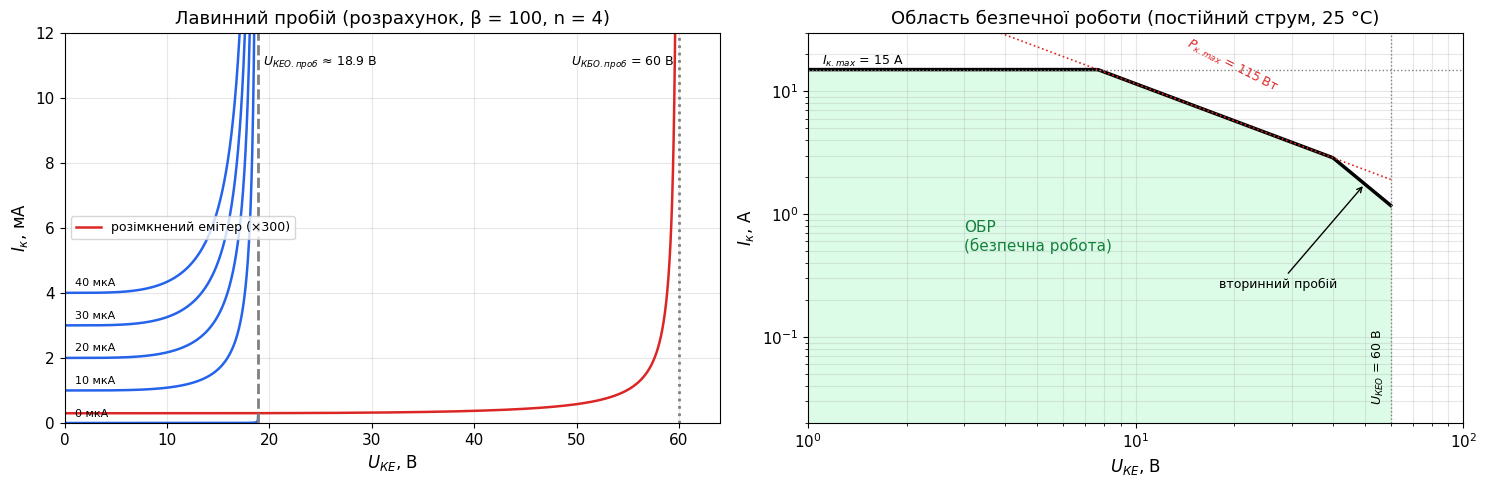

U_КЕО.проб = 60/(β+1)^(1/4) = 18.9 В


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# (а) Вихідні характеристики з лавинним множенням: αM → 1
BVCBO, n, beta0 = 60.0, 4.0, 100.0
alpha0 = beta0/(beta0 + 1)
BVCEO = BVCBO/(beta0 + 1)**(1/n)
U = np.linspace(0, 64, 3000)
M = 1/(1 - np.clip(U/BVCBO, 0, 0.99999)**n)
for Ib in [0, 10e-6, 20e-6, 30e-6, 40e-6]:
    aM = alpha0*M
    Ic = np.where(aM < 1, (aM*Ib + M*1e-8)/(1 - aM), np.nan)          # I_к = (αM·I_б + M·I_КБО)/(1 − αM)
    axes[0].plot(U, Ic*1e3, color='#2563eb', lw=1.8)
    axes[0].text(1, (alpha0*Ib/(1 - alpha0))*1e3 + 0.2, f'{Ib*1e6:.0f} мкА', fontsize=8)
Icb = 1e-6*M                                                          # емітер розімкнений: I_к = M·I_КБО
axes[0].plot(U, np.where(U < BVCBO*0.9999, Icb*1e3*300, np.nan), color='#dc2626', lw=1.8, label='розімкнений емітер (×300)')
axes[0].axvline(BVCEO, color='gray', ls='--'); axes[0].text(BVCEO + 0.5, 11, f'$U_{{КЕО.проб}}$ ≈ {BVCEO:.1f} В', fontsize=9)
axes[0].axvline(BVCBO, color='gray', ls=':'); axes[0].text(BVCBO - 0.5, 11, f'$U_{{КБО.проб}}$ = {BVCBO:.0f} В', ha='right', fontsize=9)
axes[0].set_ylim(0, 12); axes[0].set_xlim(0, 64); axes[0].legend(fontsize=9, loc='center left')
axes[0].set_xlabel('$U_{КЕ}$, В'); axes[0].set_ylabel('$I_к$, мА'); axes[0].set_title('Лавинний пробій (розрахунок, β = 100, n = 4)')
# (б) ОБР потужного транзистора (дані типу 2N3055: 15 А, 115 Вт, 60 В)
Icmax, Pmax, Uceo, Usb = 15.0, 115.0, 60.0, 40.0
u = np.logspace(0, np.log10(Uceo), 300)
lim = np.minimum(Icmax, Pmax/u)
sb = Pmax/Usb*(u/Usb)**-2.2                                          # вторинний пробій: крутіший спад вище Usb
lim = np.where(u > Usb, np.minimum(lim, sb), lim)
axes[1].loglog(u, lim, 'k', lw=2.5)
axes[1].fill_between(u, 1e-2, lim, color='#dcfce7')
axes[1].loglog(u, Pmax/u, ':', color='#dc2626', lw=1.2); axes[1].text(14, Pmax/14*1.2, '$P_{к.max}$ = 115 Вт', color='#dc2626', rotation=-27, fontsize=9)
axes[1].axhline(Icmax, color='gray', ls=':', lw=1); axes[1].text(1.1, Icmax*1.1, '$I_{к.max}$ = 15 А', fontsize=9)
axes[1].axvline(Uceo, color='gray', ls=':', lw=1); axes[1].text(Uceo*0.97, 0.03, '$U_{КЕО}$ = 60 В', rotation=90, ha='right', fontsize=9)
axes[1].annotate('вторинний пробій', xy=(50, float(Pmax/Usb*(50/Usb)**-2.2)), xytext=(18, 0.25), arrowprops=dict(arrowstyle='->'), fontsize=9)
axes[1].text(3, 0.5, 'ОБР\n(безпечна робота)', fontsize=11, color='#15803d')
axes[1].set_xlim(1, 100); axes[1].set_ylim(0.02, 30); axes[1].grid(True, which='both', alpha=0.3)
axes[1].set_xlabel('$U_{КЕ}$, В'); axes[1].set_ylabel('$I_к$, А'); axes[1].set_title('Область безпечної роботи (постійний струм, 25 °C)')
plt.tight_layout(); plt.show()
print(f'U_КЕО.проб = {BVCBO:.0f}/(β+1)^(1/{n:.0f}) = {BVCEO:.1f} В')

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте **$U_{КБО.max}$** (пробій колекторного переходу при розімкненому емітері — найбільша напруга в довіднику) з **$U_{КЕО.max}$** (колектор–емітер при розімкненій базі — у кілька разів менша). Розрахунок ключа за $U_{КБО}$ — типова причина пробою «справного за паспортом» транзистора вже при номінальній напрузі живлення.

</div>

---
### ✅ Питання для самоперевірки: Температура, пробій, ОБР

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому при фіксованому струмі бази робоча точка сильно залежить від температури?</summary>

> **Відповідь:** Колекторний струм $I_к = \beta I_б + (\beta+1)I_{КБО}$, а β і $I_{КБО}$ зростають з температурою. Кола зворотного зв'язку, яке компенсувало б це зростання, немає.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому $U_{КЕО.проб} < U_{КБО.проб}$?</summary>

> **Відповідь:** При розімкненій базі лавинно згенеровані носії колекторного переходу діють як додатковий струм бази й підсилюються в β разів. Пробій настає вже тоді, коли $\alpha M = 1$, тобто при значно меншому $M$ і меншій напрузі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому межі ОБР у логарифмічному масштабі — прямі лінії?</summary>

> **Відповідь:** $I_{к.max}$ = const — горизонталь; $P = UI$ = const → $\lg I = \lg P - \lg U$ — пряма з нахилом −1; вторинний пробій апроксимується степеневою залежністю $I \propto U^{-k}$ (k ≈ 2–4) — теж пряма; $U_{КЕО}$ — вертикаль.

</details>

---
### 📝 Задачі для самостійного розв'язання: Статичні характеристики та параметри БТ


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** За вихідними характеристиками 2N3904 при $U_{КЕ}$ = 5 В струм колектора дорівнює 3,3 мА при $I_б$ = 20 мкА і 5,0 мА при $I_б$ = 30 мкА. Знайдіть статичний і диференціальний коефіцієнти передачі струму.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Статичний: $\beta = 3{,}3/0{,}02 = 165$ (при 20 мкА); диференціальний: $h_{21е} = (5{,}0 - 3{,}3)/(30 - 20)\cdot10^3 = 170$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Транзистор: $I_к$ = 1 мА, β = 150, $r_б$ = 100 Ом. Знайдіть $r_е$, $h_{11е}$ і крутизну $g_m$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $r_е = \varphi_T/I_е = 25{,}85/1{,}0067 \approx 25{,}7$ Ом; $h_{11е} = r_б + (\beta+1)r_е = 100 + 151\cdot25{,}7 \approx 3{,}98$ кОм; $g_m = I_к/\varphi_T = 38{,}7$ мА/В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Напруга Ерлі 74 В, $I_к$ = 1 мА, $U_{КЕ}$ = 5 В. Знайдіть вихідну провідність і вихідний опір у схемі СЕ.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $h_{22е} = I_к/(U_A + U_{КЕ}) = 1/79 = 12{,}7$ мкСм; $r_{ке} = 1/h_{22е} = 79$ кОм.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** $U_{КБО.проб}$ = 60 В, β = 100, n = 4. Оцініть $U_{КЕО.проб}$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{КЕО.проб} = 60/\sqrt[4]{101} = 60/3{,}170 \approx 18{,}9$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 5.** Каскад СЕ: $E_к$ = 12 В, $R_к$ = 2 кОм, β = 165, $I_б$ = 20 мкА. Знайдіть робочу точку. Яким має бути $I_б$, щоб транзистор увійшов у насичення?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_к = \beta I_б = 3{,}3$ мА; $U_{КЕ} = 12 - 3{,}3\cdot2 = 5{,}4$ В — активний режим. Насичення: $I_{к.нас} \approx (12 - 0{,}2)/2 = 5{,}9$ мА, $I_б > 5{,}9/165 \approx 36$ мкА.

</details>

---

## 📌 Підсумок лекції 6: Статичні характеристики та параметри біполярного транзистора <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Характеристика / параметр | Що показує | Типові значення (малопотужний Si БТ) |
|---|---|---|
| Вхідна СЕ $I_б(U_{БЕ})$ | експоненційна ВАХ емітерного переходу | $U_{БЕ}$ ≈ 0,6–0,75 В |
| Вихідна СЕ $I_к(U_{КЕ})$ | насичення / активна / відсічка / пробій | $U_{КЕ.нас}$ ≈ 0,1–0,3 В |
| Напруга Ерлі $U_A$ | нахил вихідних характеристик | 50–200 В |
| $h_{11е} = r_б + (\beta+1)\varphi_T/I_е$ | вхідний опір | 1–10 кОм при 1 мА |
| $h_{21е} = \beta$ | підсилення струму | 50–500, максимум при середніх струмах |
| $h_{22е} = I_к/(U_A + U_{КЕ})$ | вихідна провідність | 5–100 мкСм |
| $U_{КЕО.проб} = U_{КБО.проб}/\sqrt[n]{\beta+1}$ | допустима напруга | у 2–4 рази менша за $U_{КБО}$ |

**Головні висновки.** (1) Сімейства характеристик повністю описують транзистор на постійному струмі і дозволяють графічно знайти робочу точку та h-параметри. (2) h-параметри залежать від робочої точки: $h_{11е} \propto 1/I_к$, $h_{22е} \propto I_к$. (3) Параметри транзистора сильно залежать від температури і розкиду β; схема зміщення з емітерною стабілізацією робить робочу точку стабільною. (4) Граничні режими (пробій, потужність, вторинний пробій) визначають ОБР, за яку не можна виходити.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 5. Біполярний транзистор: будова, принцип дії, режими](Лекція_05_Біполярний_транзистор_принцип_дії.ipynb) &nbsp;|&nbsp; [Лекція 7. Біполярний транзистор у підсилювальному та ключовому режимах](Лекція_07_Біполярний_транзистор_у_динамічному_режимі.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*